In [ ]:
# Step_1:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import random

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [10]:
# Step_2:
# Load MNIST dataset from CSV files
train_csv_path = '//content/sample_data/mnist_train_small.csv'
test_csv_path = '/content/sample_data/mnist_test.csv'

train_data = pd.read_csv(train_csv_path)
test_data = pd.read_csv(test_csv_path)

# Load training data
# The first line is the label, the rest are pixel values
train_data = pd.read_csv(train_csv_path, header=None)
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
X_train = X_train.reshape(X_train.shape[0], 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv(test_csv_path, header=None)
y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values
X_test = X_test.reshape(X_test.shape[0], 28, 28)

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(X_test.shape[0], 28, 28)

# Display the shapes of training and test sets
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

Training data shape: (20000, 28, 28)
Training labels shape: (20000,)


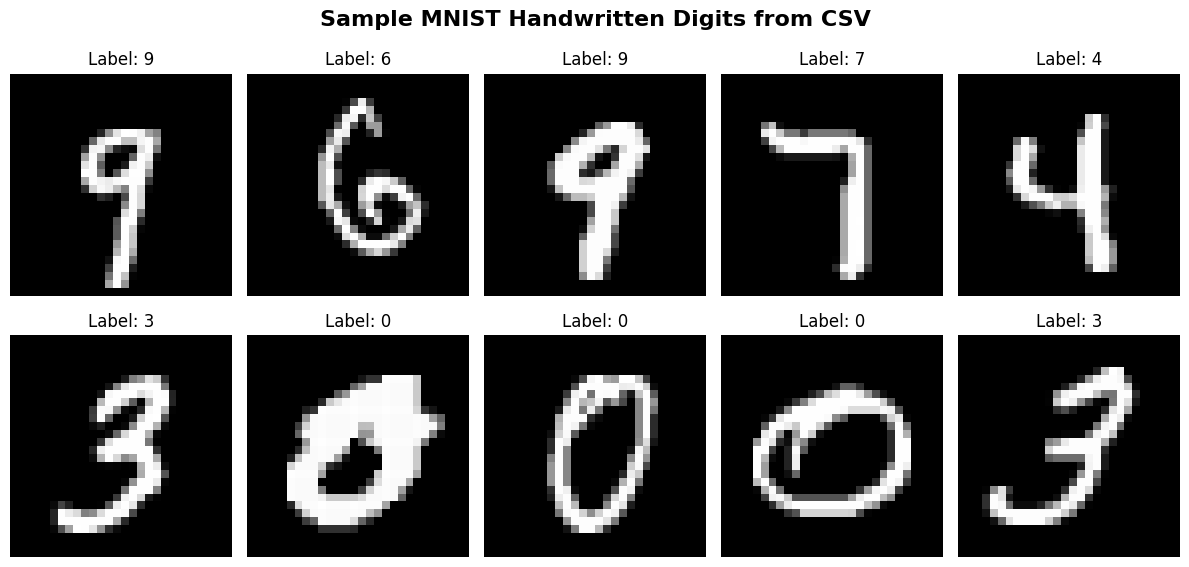

In [11]:
# Step_3:
# Plot 10 random sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits from CSV', fontsize=16, fontweight='bold')

# Set random seed for reproducibility
random.seed(42)

# Pick 10 unique random indices
indices = random.sample(range(len(X_train)), 10)

for i, idx in enumerate(indices):
    row = i // 5
    col = i % 5

    image = X_train[idx]
    label = y_train[idx]

    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [20]:
# Step 4: Create MLP model according to given template
import tensorflow as tf

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        tf.keras.layers.Dense(128, activation='relu'),

        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        tf.keras.layers.Dropout(0.2),

        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        tf.keras.layers.Dense(64, activation='relu'),

        # Another dropout layer for regularization, same with above
        tf.keras.layers.Dropout(0.2),

        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',  # use sparse labels (integer 0-9)
        metrics=['accuracy']
    )
    return model

# Creating the MLP model
mlp_model = create_mlp_model()
print("MLP Model created")

# Print model summary to check
mlp_model.summary()


MLP Model created


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Step 4.8: Training parameters
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Normalize pixel values (0-255 → 0-1)
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# If using sparse_categorical_crossentropy, labels remain integers
y_train_categorical = y_train
y_test_categorical = y_test

# Train MLP model using mlp_model we compiled.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("MLP training completed")


MLP training completed
